# Lab 10 — Métodos de Propagación de Etiquetas
**Grupo 03** | Minería de Datos — Sección 20  
Universidad del Valle de Guatemala

**Integrantes:** Felipe Aguilar, Vianka Castro, Nicolás Concuá, Ricardo Godínez, Fernando Hernández, Fernando Rueda

---

## Fase 2 — Selección y Análisis de Dataset

**Dataset:** Red Wine Quality  
**Fuente:** UCI Machine Learning Repository / Kaggle  
**Algoritmos a aplicar:** Label Propagation & Label Spreading

---
## 2a. Importación del Dataset

In [6]:
import numpy as np
import pandas as pd

df = pd.read_csv('winequality-red.csv', sep=';')

print('Dataset cargado exitosamente.')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

Dataset cargado exitosamente.
Dimensiones: 1599 filas x 12 columnas


In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


In [8]:
print('Columnas del dataset:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Columnas del dataset:
   1. fixed acidity
   2. volatile acidity
   3. citric acid
   4. residual sugar
   5. chlorides
   6. free sulfur dioxide
   7. total sulfur dioxide
   8. density
   9. pH
  10. sulphates
  11. alcohol
  12. quality


In [9]:
feature_cols = [c for c in df.columns if c != 'quality']
X = df[feature_cols]
y_raw = df['quality']

df['quality_label'] = (df['quality'] >= 7).astype(int)
df['quality_str']   = df['quality_label'].map({0: 'bad', 1: 'good'})
y = df['quality_label']

print(f'Features : {len(feature_cols)}')
print(f'Target   : quality binarizado (>=7 = good, <7 = bad)')
print(f'Muestras : {len(df)}')

Features : 11
Target   : quality binarizado (>=7 = good, <7 = bad)
Muestras : 1599


---
## 2b. Análisis Exploratorio de Datos (EDA)

### Tipos de variables y dimensionalidad

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

In [11]:
type_summary = pd.DataFrame({
    'dtype'      : df[feature_cols].dtypes,
    'non_null'   : df[feature_cols].notna().sum(),
    'null'       : df[feature_cols].isna().sum(),
    'unique_vals': df[feature_cols].nunique()
})

print('=== Resumen de tipos de variables ===')
print(type_summary.to_string())
print(f'\nFeatures numericas  : {df[feature_cols].select_dtypes(include=np.number).shape[1]}')
print(f'Features categoricas: {df[feature_cols].select_dtypes(include="object").shape[1]}')

=== Resumen de tipos de variables ===
                        dtype  non_null  null  unique_vals
fixed acidity         float64      1599     0           96
volatile acidity      float64      1599     0          143
citric acid           float64      1599     0           80
residual sugar        float64      1599     0           91
chlorides             float64      1599     0          153
free sulfur dioxide   float64      1599     0           60
total sulfur dioxide  float64      1599     0          144
density               float64      1599     0          436
pH                    float64      1599     0           89
sulphates             float64      1599     0           96
alcohol               float64      1599     0           65

Features numericas  : 11
Features categoricas: 0


In [12]:
print(f'Dimensionalidad del espacio de features: {X.shape[1]} dimensiones')
print(f'Numero de muestras                     : {X.shape[0]}')
print(f'\nDistribucion de scores de calidad originales:')
print(y_raw.value_counts().sort_index().to_string())

Dimensionalidad del espacio de features: 11 dimensiones
Numero de muestras                     : 1599

Distribucion de scores de calidad originales:
quality
3     10
4     53
5    681
6    638
7    199
8     18


### Balance de clases

=== Balance de clases (binarizado) ===
  bad   :  1382 muestras (86.4%)
  good  :   217 muestras (13.6%)


/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/3332090793.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality_str', ax=axes[1], order=['bad', 'good'], palette=palette)


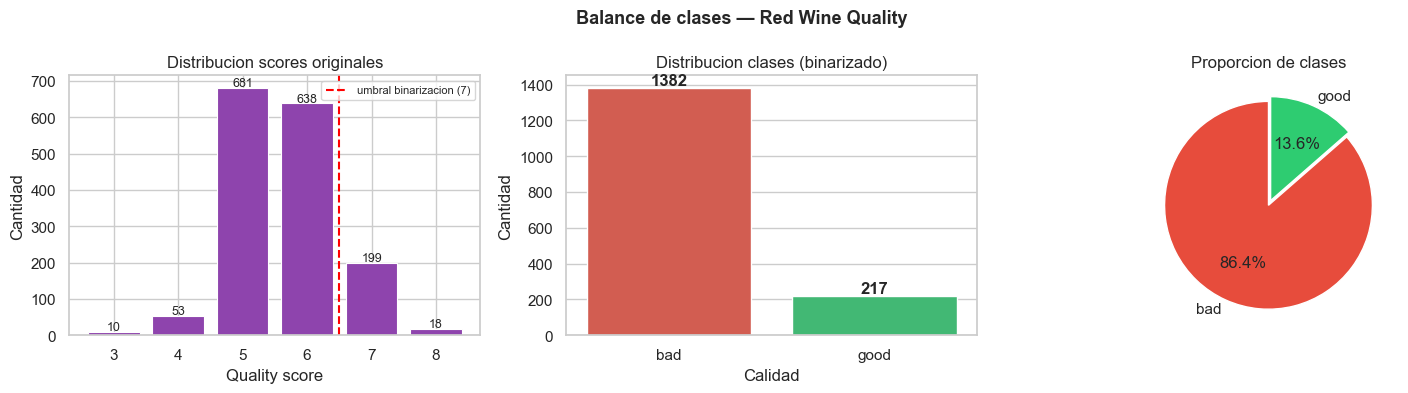

In [13]:
class_counts = df['quality_str'].value_counts()
class_pct    = df['quality_str'].value_counts(normalize=True) * 100

print('=== Balance de clases (binarizado) ===')
for cls in class_counts.index:
    print(f'  {cls:6s}: {class_counts[cls]:5d} muestras ({class_pct[cls]:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = {'bad': '#e74c3c', 'good': '#2ecc71'}

score_counts = y_raw.value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='#8e44ad', edgecolor='white', linewidth=0.8)
axes[0].axvline(x=6.5, color='red', linestyle='--', linewidth=1.5, label='umbral binarizacion (7)')
axes[0].set_title('Distribucion scores originales')
axes[0].set_xlabel('Quality score')
axes[0].set_ylabel('Cantidad')
axes[0].legend(fontsize=8)
for k, v in score_counts.items():
    axes[0].text(k, v + 5, str(v), ha='center', fontsize=9)

sns.countplot(data=df, x='quality_str', ax=axes[1], order=['bad', 'good'], palette=palette)
axes[1].set_title('Distribucion clases (binarizado)')
axes[1].set_xlabel('Calidad')
axes[1].set_ylabel('Cantidad')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[2].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90, explode=(0, 0.05))
axes[2].set_title('Proporcion de clases')

plt.suptitle('Balance de clases — Red Wine Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Estadísticas descriptivas

In [14]:
desc = X.describe().T
desc['cv'] = (desc['std'] / desc['mean']).round(3)
desc = desc[['mean', 'std', 'cv', 'min', '25%', '50%', '75%', 'max']]
desc.columns = ['Media', 'Std', 'CV', 'Min', 'Q1', 'Mediana', 'Q3', 'Max']

print('=== Estadisticas descriptivas (features) ===')
desc.round(4)

=== Estadisticas descriptivas (features) ===


,Media,Std,CV,Min,Q1,Mediana,Q3,Max
fixed acidity,8.3196,1.7411,0.2090,4.6000,7.1000,7.9000,9.2000,15.9000
volatile acidity,0.5278,0.1791,0.3390,0.1200,0.3900,0.5200,0.6400,1.5800
citric acid,0.2710,0.1948,0.7190,0.0000,0.0900,0.2600,0.4200,1.0000
residual sugar,2.5388,1.4099,0.5550,0.9000,1.9000,2.2000,2.6000,15.5000
chlorides,0.0875,0.0471,0.5380,0.0120,0.0700,0.0790,0.0900,0.6110
free sulfur dioxide,15.8749,10.4602,0.6590,1.0000,7.0000,14.0000,21.0000,72.0000
total sulfur dioxide,46.4678,32.8953,0.7080,6.0000,22.0000,38.0000,62.0000,289.0000
density,0.9967,0.0019,0.0020,0.9901,0.9956,0.9968,0.9978,1.0037
pH,3.3111,0.1544,0.0470,2.7400,3.2100,3.3100,3.4000,4.0100
sulphates,0.6581,0.1695,0.2580,0.3300,0.5500,0.6200,0.7300,2.0000


### Distribución de features por clase

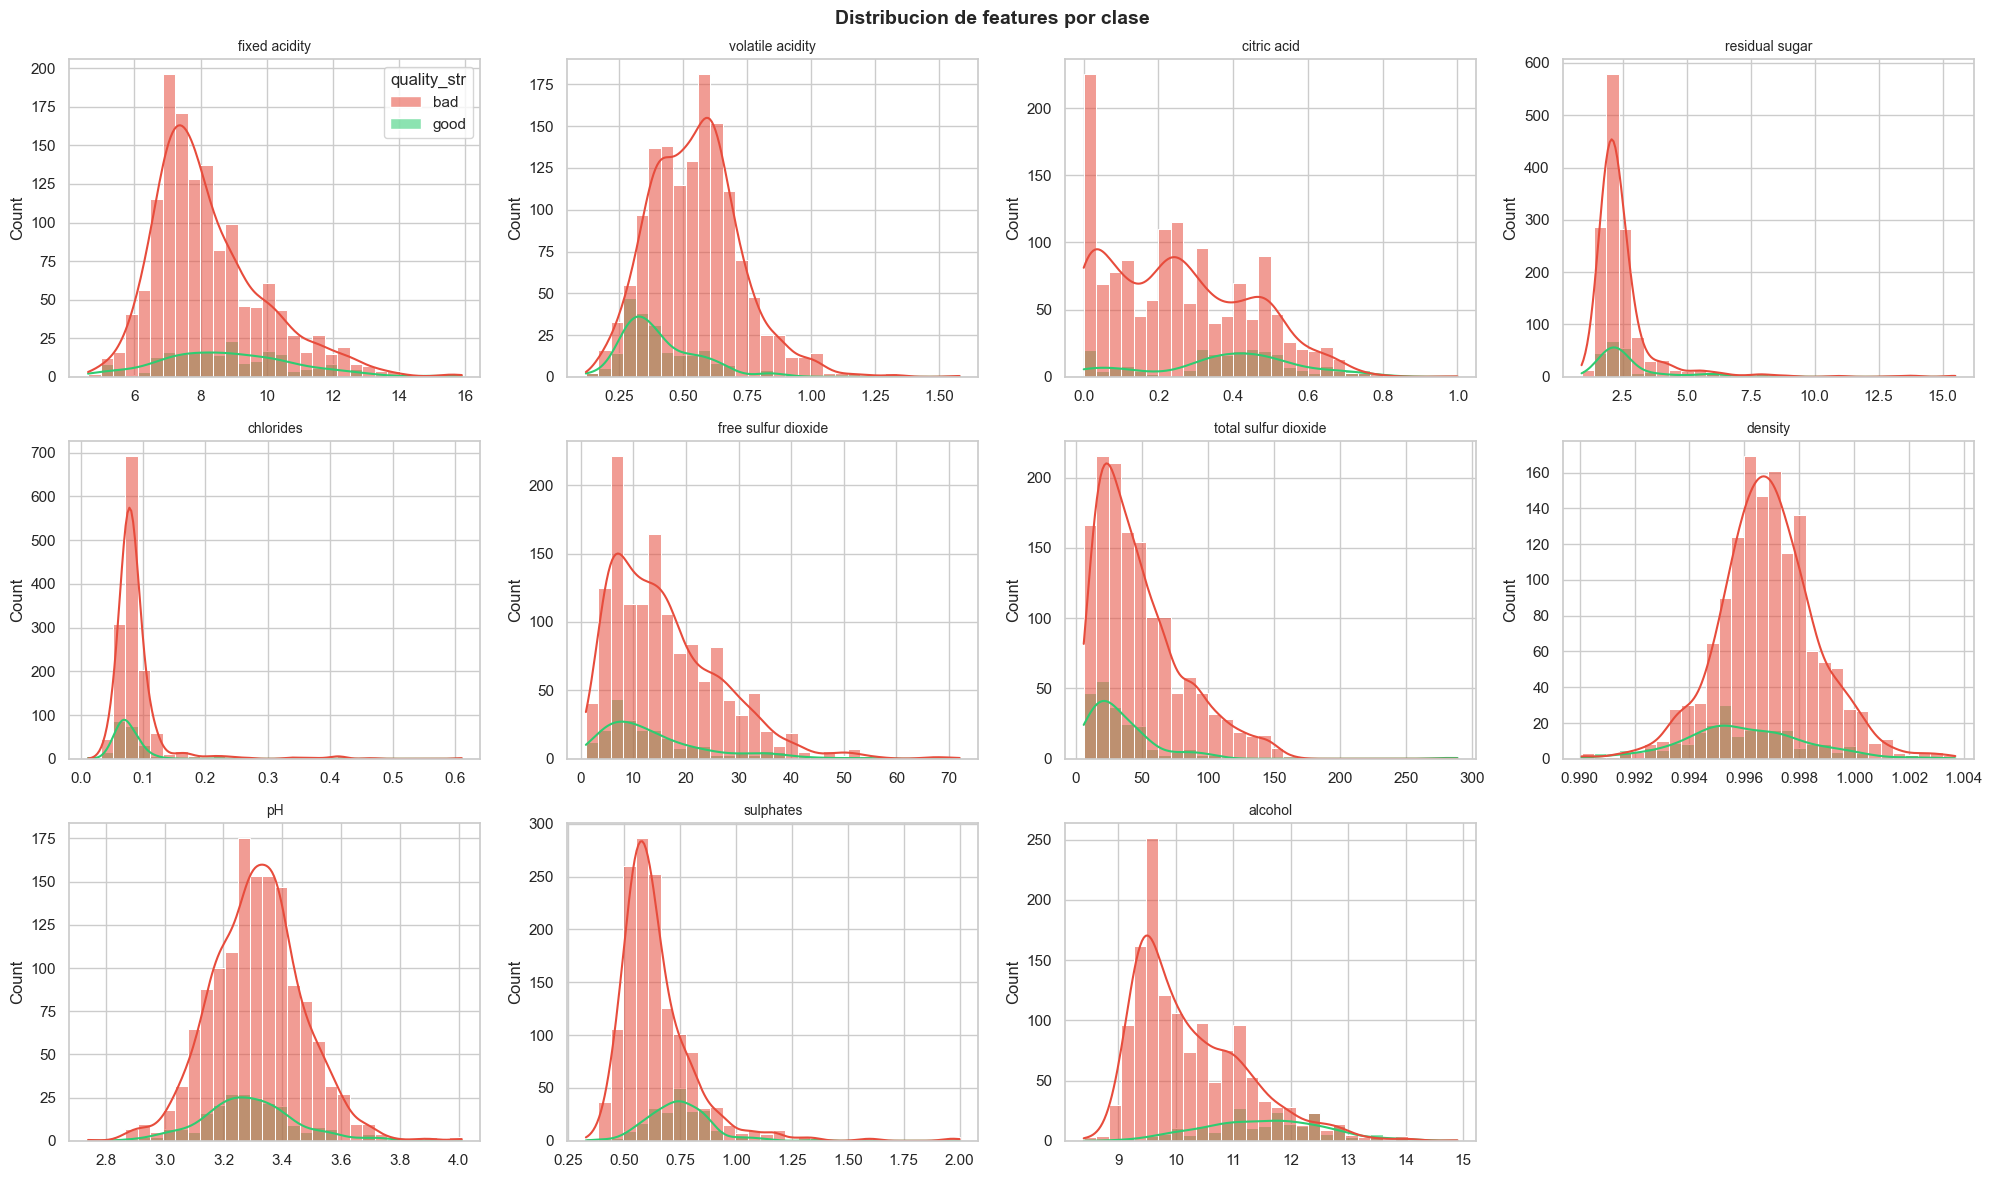

In [15]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    sns.histplot(data=df, x=feat, hue='quality_str',
                 ax=axes[i], kde=True, palette=palette, alpha=0.55, bins=30)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    if i != 0:
        axes[i].get_legend().remove()

axes[-1].set_visible(False)
plt.suptitle('Distribucion de features por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Boxplots por clase

/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/3764850149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_str', y=feat,
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/3764850149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_str', y=feat,
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/3764850149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality_str', y=feat,
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18

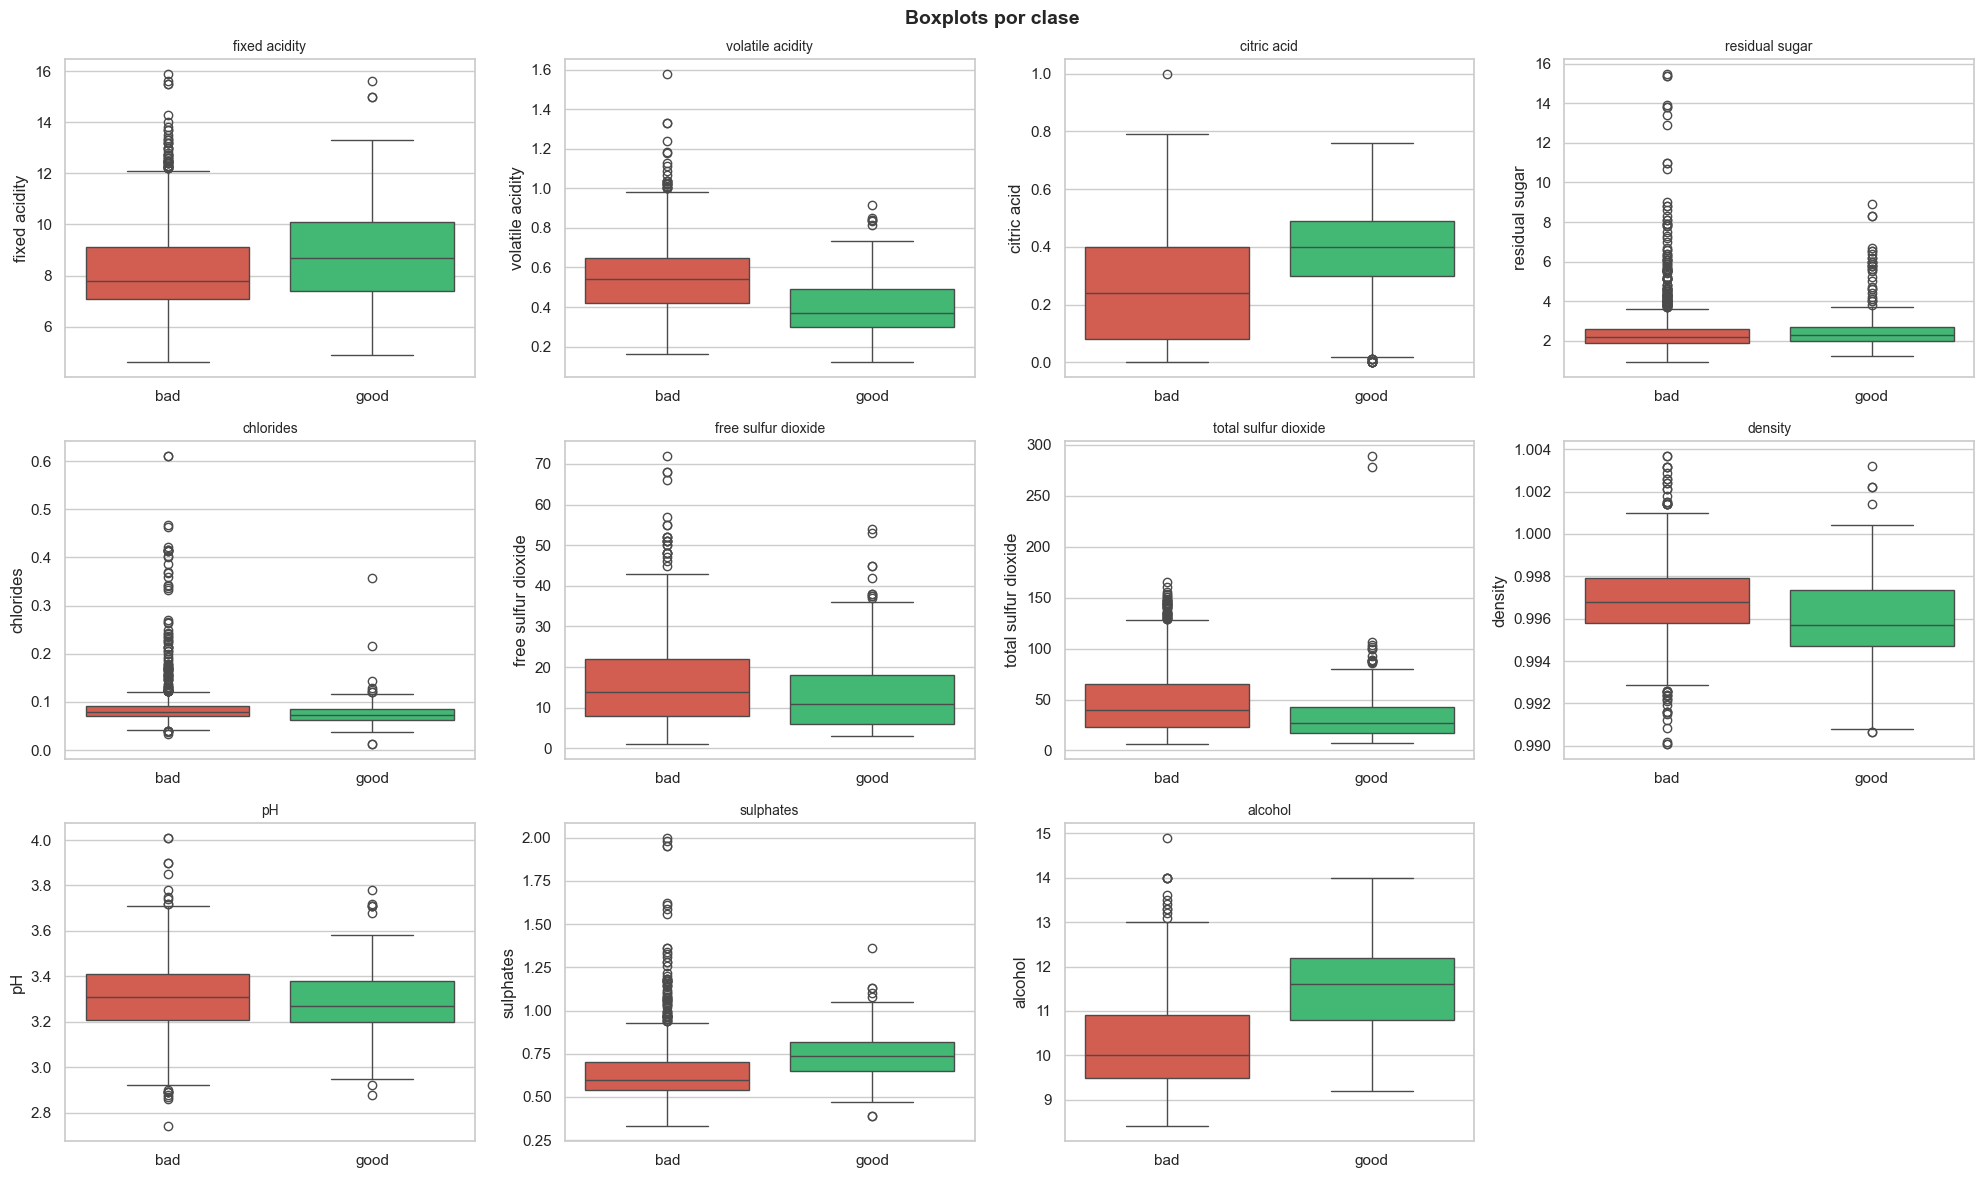

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    sns.boxplot(data=df, x='quality_str', y=feat,
                ax=axes[i], palette=palette, order=['bad', 'good'])
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Boxplots por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Matriz de correlación

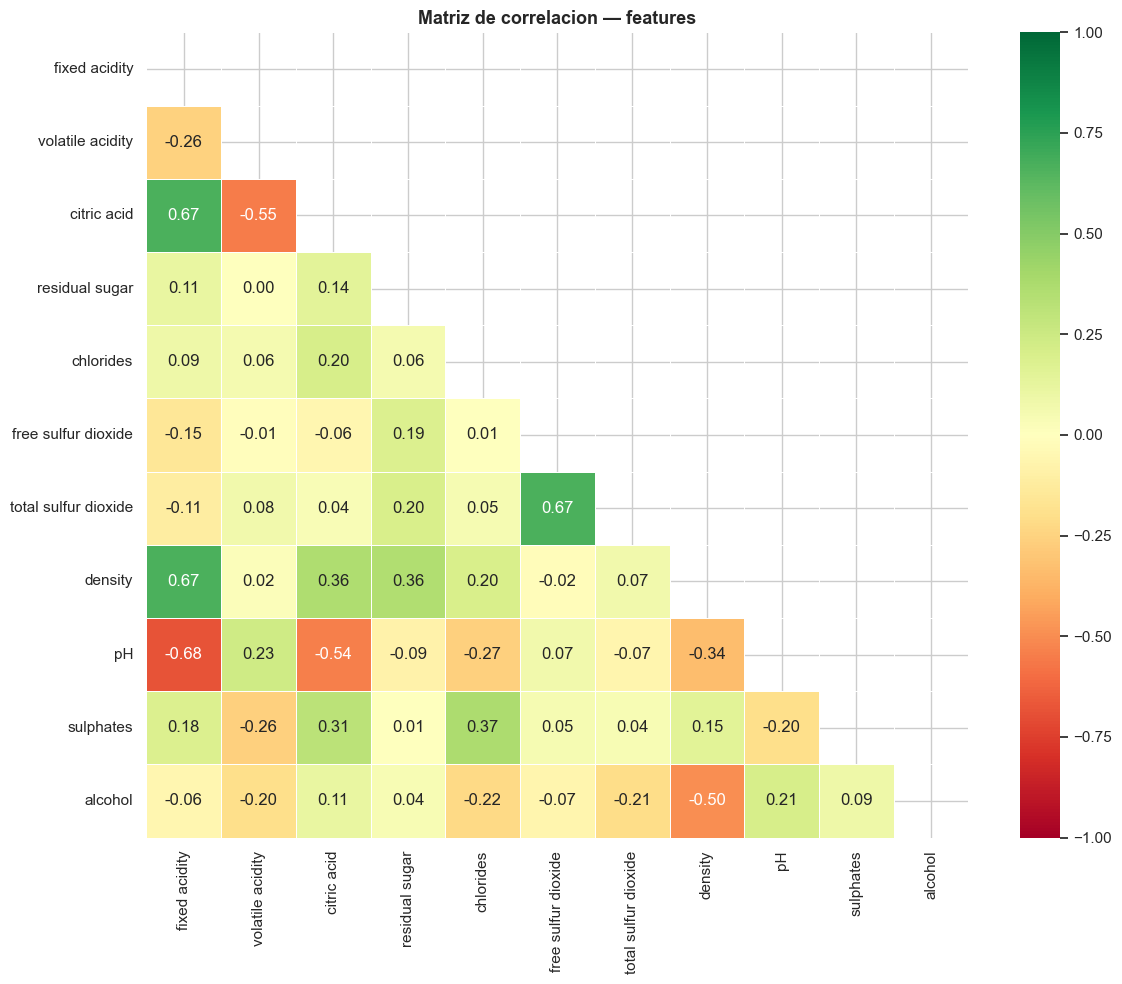

Pares con |r| > 0.70:


In [17]:
corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlacion — features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print('Pares con |r| > 0.70:')
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f'  {a:30s} <-> {b:30s}  r = {r}')

### Correlación de cada feature con el score de calidad

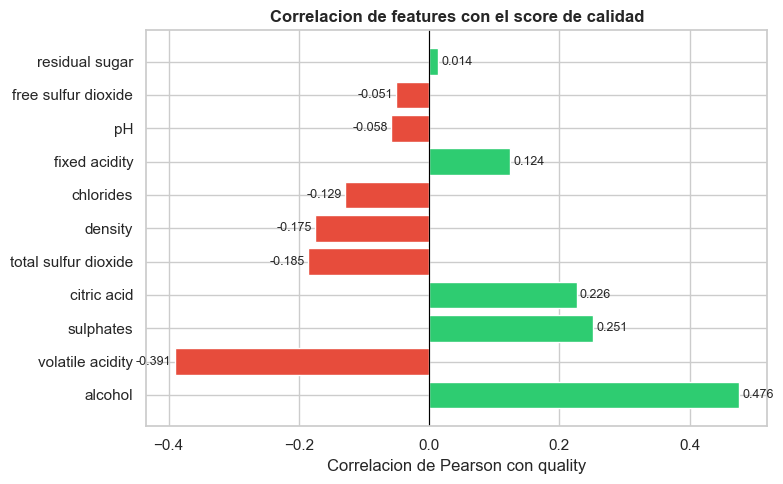

In [18]:
corr_with_target = X.corrwith(y_raw).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con quality')
ax.set_title('Correlacion de features con el score de calidad', fontsize=12, fontweight='bold')
for feat, val in corr_with_target.items():
    ax.text(val + (0.005 if val >= 0 else -0.005), list(corr_with_target.index).index(feat),
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

### Detección de outliers (IQR)

=== Outliers por feature (criterio IQR) ===
residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
volatile acidity         19
alcohol                  13
citric acid               1

Muestras con al menos 1 outlier: 405 / 1599


/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/507606013.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=feat, x='quality_str',
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/507606013.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=feat, x='quality_str',
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18864/507606013.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=feat, x='quality_str',
/var/folders/p7/zzx1y7p97rz1hp9y9snvw1kw0000gn/T/ipykernel_18

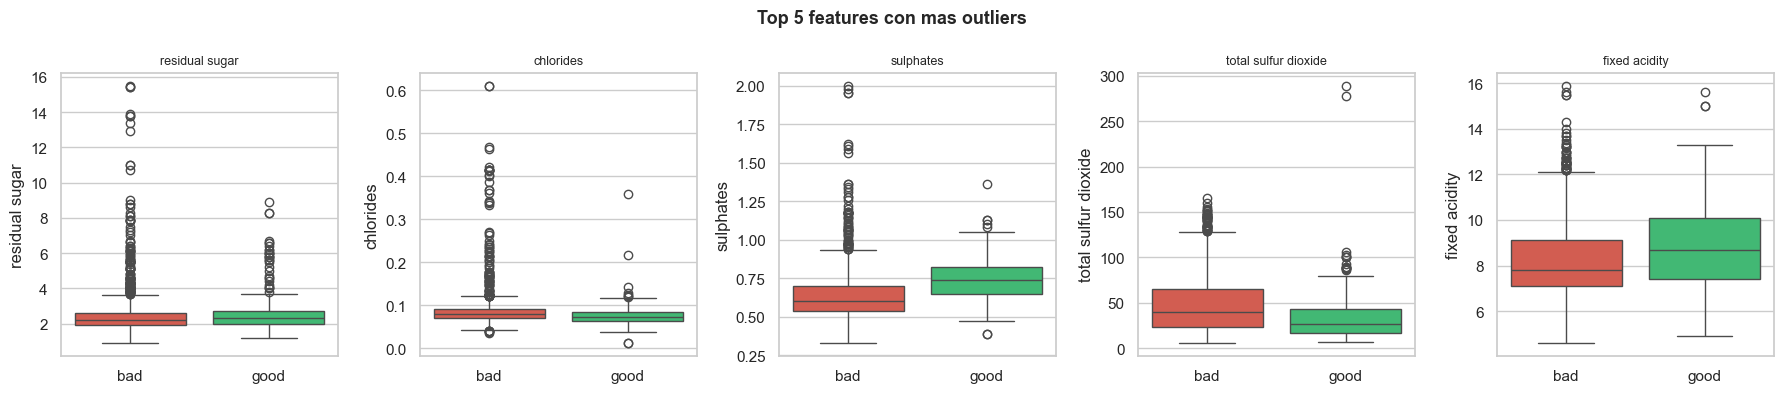

In [19]:
Q1  = X.quantile(0.25)
Q3  = X.quantile(0.75)
IQR = Q3 - Q1

outlier_mask   = (X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum().sort_values(ascending=False)

print('=== Outliers por feature (criterio IQR) ===')
print(outlier_counts[outlier_counts > 0].to_string())
print(f'\nMuestras con al menos 1 outlier: {outlier_mask.any(axis=1).sum()} / {len(df)}')

top5 = outlier_counts.head(5).index.tolist()
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(top5):
    sns.boxplot(data=df, y=feat, x='quality_str',
                ax=axes[i], palette=palette, order=['bad', 'good'])
    axes[i].set_title(feat[:20], fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Top 5 features con mas outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Proyección PCA — separabilidad visual

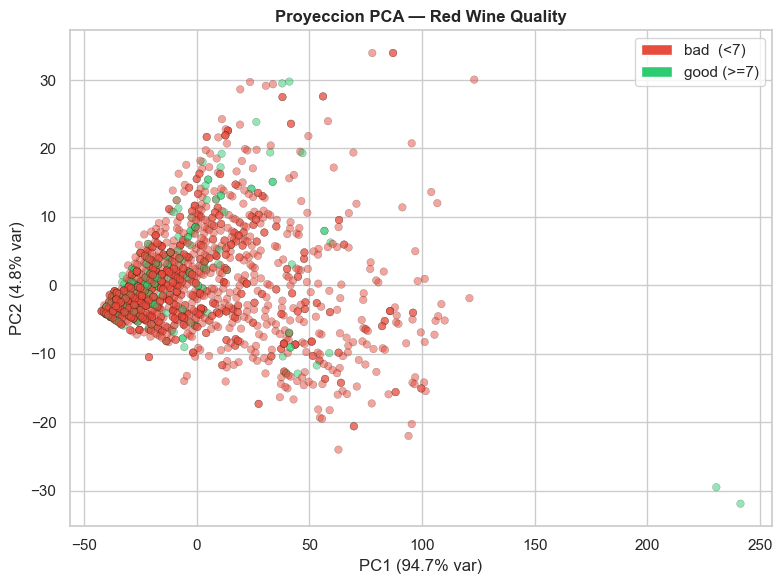

Varianza explicada acumulada: 99.49%


In [20]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

colors = y.map({0: '#e74c3c', 1: '#2ecc71'})
legend_elements = [Patch(facecolor='#e74c3c', label='bad  (<7)'),
                   Patch(facecolor='#2ecc71', label='good (>=7)')]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5,
           edgecolors='k', linewidths=0.2, s=30)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Proyeccion PCA — Red Wine Quality', fontsize=12, fontweight='bold')
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print(f'Varianza explicada acumulada: {sum(pca.explained_variance_ratio_)*100:.2f}%')

### Valores faltantes

In [21]:
missing = X.isna().sum()
print('=== Valores faltantes por feature ===')
if missing.sum() == 0:
    print('  No se encontraron valores faltantes. OK')
else:
    print(missing[missing > 0])

=== Valores faltantes por feature ===
  No se encontraron valores faltantes. OK


---
## 2c–2d. Preprocesamiento de Datos

Los kernels RBF y k-NN de Label Propagation/Spreading dependen de **distancias euclidianas**. Las 11 features del dataset tienen rangos muy distintos (p.ej. `total sulfur dioxide` llega a ~289 mientras `density` ronda 0.99), lo que distorsionaría la matriz de afinidad W sin estandarización.

Pasos aplicados:
1. **Variables categóricas**: ninguna — no se requiere encoding.
2. **Outliers**: se conservan; los métodos de propagación son robustos a ruido moderado y eliminarlos reduciría muestras valiosas de la clase minoritaria (`good`).
3. **Estandarización z-score** (`StandardScaler`): media 0, std 1 en cada feature.
4. **Construcción del conjunto semi-supervisado**: 20% etiquetado / 80% con `y = -1`.

### Verificación de variables categóricas

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

cat_cols = X.select_dtypes(include='object').columns.tolist()
if len(cat_cols) == 0:
    print('No existen variables categoricas. One-hot encoding no requerido. OK')
else:
    print(f'Variables categoricas encontradas: {cat_cols}')

No existen variables categoricas. One-hot encoding no requerido. OK


### Decisión sobre outliers

In [23]:
outliers_por_clase = pd.DataFrame({
    'total_outliers': outlier_mask.sum(axis=1),
    'clase': df['quality_str']
})

print('Outliers por clase:')
print(outliers_por_clase.groupby('clase')['total_outliers'].describe().round(2))
print()
print('Muestras de clase "good" con outliers:',
      outlier_mask.any(axis=1)[y == 1].sum(), '/', (y == 1).sum())
print('Decision: se conservan los outliers para no perder muestras de la clase minoritaria.')

Outliers por clase:
          count   mean    std    min    25%    50%    75%    max
clase                                                           
bad   1382.0000 0.3500 0.7200 0.0000 0.0000 0.0000 0.0000 4.0000
good   217.0000 0.4300 0.7200 0.0000 0.0000 0.0000 1.0000 3.0000

Muestras de clase "good" con outliers: 70 / 217
Decision: se conservan los outliers para no perder muestras de la clase minoritaria.


### Estandarización z-score

In [24]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

stats_post = X_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
stats_post.columns = ['Media', 'Std', 'Min', 'Max']
print('=== Verificacion post-estandarizacion ===')
print(stats_post.round(4).to_string())
print(f'\nMedia global : {X_scaled_df.values.mean():.6f}  (esperado ~0)')
print(f'Std global   : {X_scaled_df.values.std():.6f}   (esperado ~1)')

=== Verificacion post-estandarizacion ===
                       Media    Std     Min     Max
fixed acidity         0.0000 1.0003 -2.1370  4.3551
volatile acidity      0.0000 1.0003 -2.2783  5.8780
citric acid          -0.0000 1.0003 -1.3915  3.7436
residual sugar       -0.0000 1.0003 -1.1627  9.1957
chlorides             0.0000 1.0003 -1.6039 11.1270
free sulfur dioxide  -0.0000 1.0003 -1.4225  5.3673
total sulfur dioxide  0.0000 1.0003 -1.2306  7.3752
density              -0.0000 1.0003 -3.5387  3.6801
pH                    0.0000 1.0003 -3.7004  4.5283
sulphates             0.0000 1.0003 -1.9365  7.9187
alcohol               0.0000 1.0003 -1.8989  4.2025

Media global : -0.000000  (esperado ~0)
Std global   : 1.000000   (esperado ~1)


### Comparación antes vs. después de estandarizar

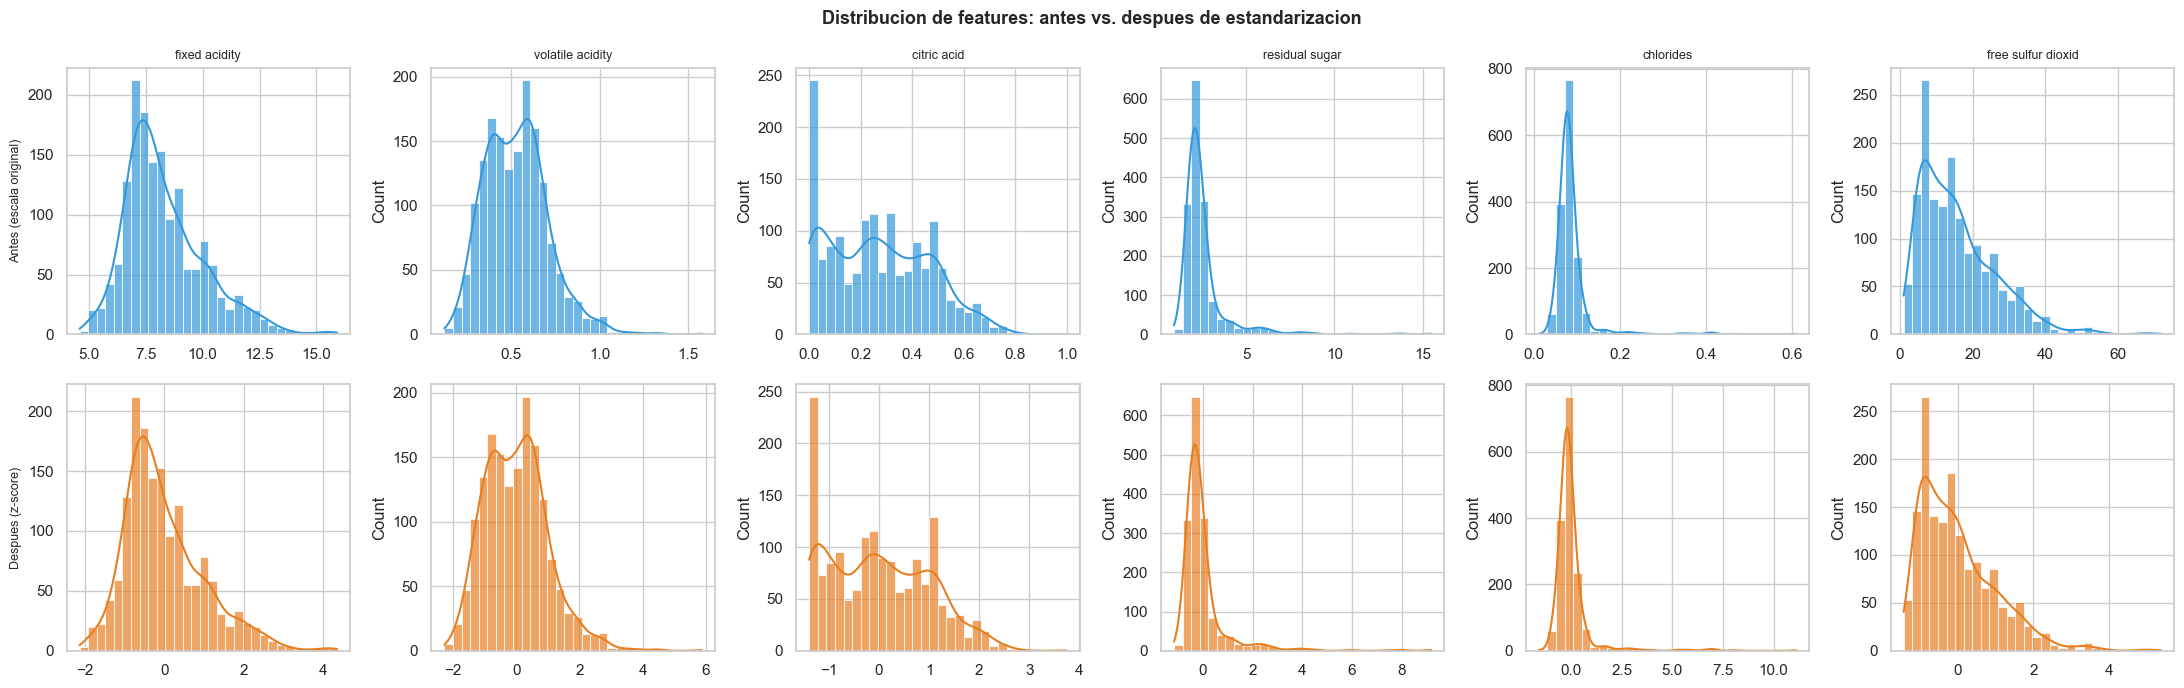

In [25]:
sample_feats = feature_cols[:6]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))

for i, feat in enumerate(sample_feats):
    sns.histplot(X[feat], ax=axes[0, i], kde=True, color='#3498db', bins=30, alpha=0.7)
    axes[0, i].set_title(feat[:18], fontsize=9)
    axes[0, i].set_xlabel('')
    if i == 0:
        axes[0, i].set_ylabel('Antes (escala original)', fontsize=9)

    sns.histplot(X_scaled_df[feat], ax=axes[1, i], kde=True, color='#e67e22', bins=30, alpha=0.7)
    axes[1, i].set_xlabel('')
    if i == 0:
        axes[1, i].set_ylabel('Despues (z-score)', fontsize=9)

plt.suptitle('Distribucion de features: antes vs. despues de estandarizacion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Impacto en distancias euclidianas

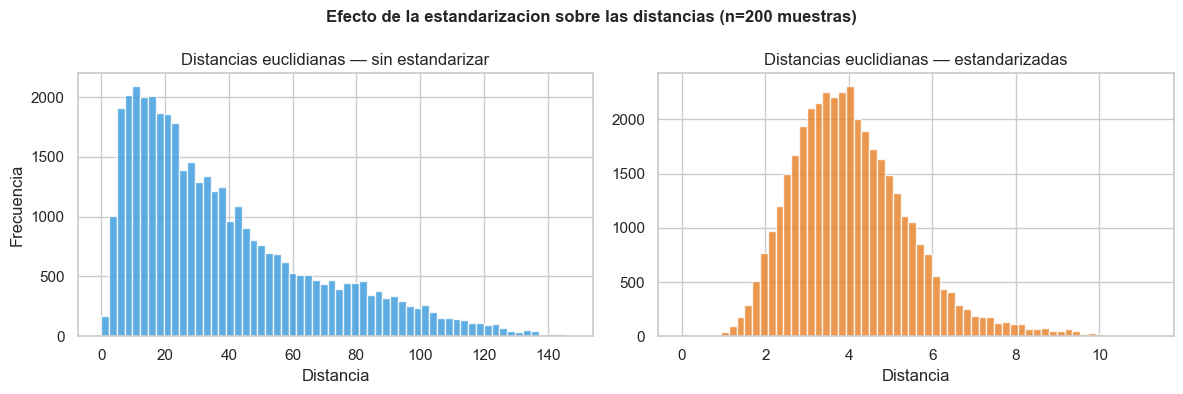

Sin estandarizar — media: 38.28, rango: [0.00, 146.91]
Estandarizadas   — media: 4.07,  rango: [0.00, 11.22]


In [26]:
from sklearn.metrics import pairwise_distances

rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=200, replace=False)

dist_before = pairwise_distances(X.values[idx], metric='euclidean').flatten()
dist_after  = pairwise_distances(X_scaled[idx],  metric='euclidean').flatten()
dist_before = dist_before[dist_before > 0]
dist_after  = dist_after[dist_after  > 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dist_before, bins=60, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Distancias euclidianas — sin estandarizar')
axes[0].set_xlabel('Distancia')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(dist_after, bins=60, color='#e67e22', alpha=0.8, edgecolor='white')
axes[1].set_title('Distancias euclidianas — estandarizadas')
axes[1].set_xlabel('Distancia')

plt.suptitle('Efecto de la estandarizacion sobre las distancias (n=200 muestras)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Sin estandarizar — media: {dist_before.mean():.2f}, rango: [{dist_before.min():.2f}, {dist_before.max():.2f}]')
print(f'Estandarizadas   — media: {dist_after.mean():.2f},  rango: [{dist_after.min():.2f}, {dist_after.max():.2f}]')

### Construcción del conjunto semi-supervisado

Label Propagation y Label Spreading requieren que la mayoría de muestras tengan `y = -1` (no etiquetadas). Se simula un escenario donde solo el **20% de las muestras tienen etiqueta conocida**, con estratificación para mantener el balance de clases.

In [27]:
LABELED_RATIO = 0.20
RANDOM_STATE  = 42

X_lab, X_unlab, y_lab, y_unlab = train_test_split(
    X_scaled, y.values,
    test_size=1 - LABELED_RATIO,
    stratify=y.values,
    random_state=RANDOM_STATE
)

y_semi = np.concatenate([y_lab, np.full(len(y_unlab), -1)])
X_semi = np.vstack([X_lab, X_unlab])

print('=== Configuracion semi-supervisada ===')
print(f'Total muestras       : {len(y_semi)}')
print(f'Etiquetadas  (20%)   : {(y_semi != -1).sum()} '
      f'[{(y_semi[y_semi != -1] == 0).sum()} bad, '
      f'{(y_semi[y_semi != -1] == 1).sum()} good]')
print(f'No etiquetadas (80%) : {(y_semi == -1).sum()}')

=== Configuracion semi-supervisada ===
Total muestras       : 1599
Etiquetadas  (20%)   : 319 [276 bad, 43 good]
No etiquetadas (80%) : 1280


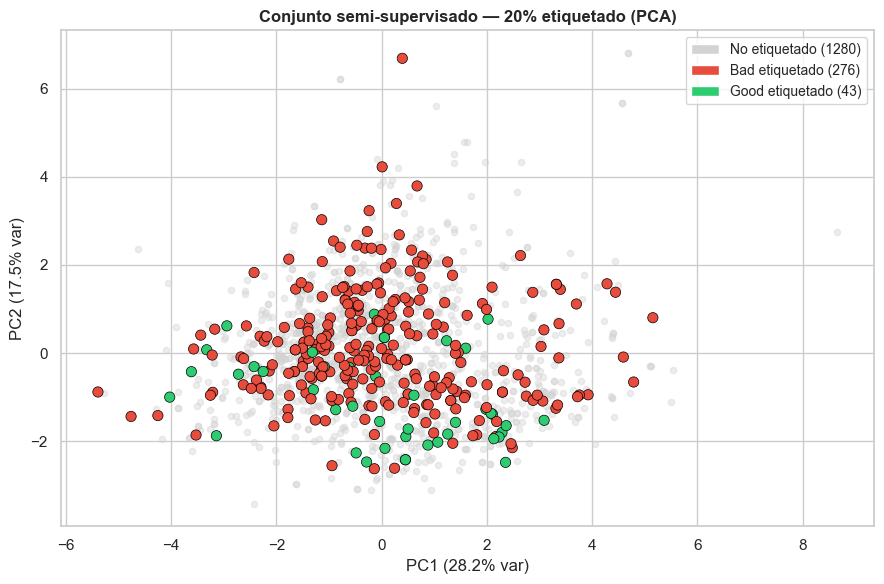

In [28]:
pca2 = PCA(n_components=2, random_state=42)
X_semi_pca = pca2.fit_transform(X_semi)

labeled_mask   = y_semi != -1
unlabeled_mask = y_semi == -1

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(X_semi_pca[unlabeled_mask, 0], X_semi_pca[unlabeled_mask, 1],
           c='lightgray', alpha=0.4, s=20, label='No etiquetado', zorder=1)

colors_lab = np.where(y_semi[labeled_mask] == 0, '#e74c3c', '#2ecc71')
ax.scatter(X_semi_pca[labeled_mask, 0], X_semi_pca[labeled_mask, 1],
           c=colors_lab, s=55, edgecolors='black', linewidths=0.5, zorder=2)

legend_elements = [
    Patch(facecolor='lightgray', label=f'No etiquetado ({unlabeled_mask.sum()})'),
    Patch(facecolor='#e74c3c',   label=f'Bad etiquetado ({(y_semi[labeled_mask]==0).sum()})'),
    Patch(facecolor='#2ecc71',   label=f'Good etiquetado ({(y_semi[labeled_mask]==1).sum()})')
]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Conjunto semi-supervisado — 20% etiquetado (PCA)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Resumen final del dataset preprocesado

In [29]:
print('=' * 52)
print('  RESUMEN — Dataset preprocesado (Fase 2)')
print('=' * 52)
print(f'  Dataset            : Red Wine Quality (UCI)')
print(f'  Muestras totales   : {X_semi.shape[0]}')
print(f'  Features           : {X_semi.shape[1]} (todas numericas)')
print(f'  Clases             : 2  (0=bad <7, 1=good >=7)')
print(f'  Valores faltantes  : 0')
print(f'  Encoding           : No requerido')
print(f'  Outliers           : conservados (clase minoritaria)')
print(f'  Escalado           : StandardScaler (z-score)')
print(f'  Etiquetadas  (20%) : {(y_semi != -1).sum()}')
print(f'  No etiquetadas(80%): {(y_semi == -1).sum()}')
print('=' * 52)
print('  Listo para Label Propagation / Label Spreading OK')
print('=' * 52)

  RESUMEN — Dataset preprocesado (Fase 2)
  Dataset            : Red Wine Quality (UCI)
  Muestras totales   : 1599
  Features           : 11 (todas numericas)
  Clases             : 2  (0=bad <7, 1=good >=7)
  Valores faltantes  : 0
  Encoding           : No requerido
  Outliers           : conservados (clase minoritaria)
  Escalado           : StandardScaler (z-score)
  Etiquetadas  (20%) : 319
  No etiquetadas(80%): 1280
  Listo para Label Propagation / Label Spreading OK


---

## Fase 3 — Diseño Experimental

### 3a. Separación de datos y evaluación de porcentajes
Para evaluar el impacto de la cantidad de datos etiquetados en el rendimiento de los modelos, realizaremos primero una partición de los datos en un conjunto de entrenamiento (80%) y uno de prueba (20%).
El conjunto de prueba se mantendrá intacto para medir el desempeño real. Sobre el conjunto de entrenamiento, evaluaremos distintos porcentajes de datos etiquetados (5%, 10%, 20%, 30%, 50%), ocultando las etiquetas del resto.

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

BASE_TEST_SIZE = 0.20
RANDOM_STATE = 42

# 1. Separación base: Train (80%) y Test (20%)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_scaled, y.values,
    test_size=BASE_TEST_SIZE,
    stratify=y.values,
    random_state=RANDOM_STATE
)

print(f'Conjunto de entrenamiento total: {X_train_base.shape[0]} muestras')
print(f'Conjunto de prueba (Hold-out test): {X_test_base.shape[0]} muestras')

# Definir porcentajes de datos etiquetados a evaluar
labeled_percentages = [0.05, 0.10, 0.20, 0.30, 0.50]

# Función para generar el conjunto de entrenamiento semi-supervisado a partir de la base de train
def create_semi_supervised_train_set(X, y_data, labeled_ratio, random_state=42):
    X_lab, X_unlab, y_lab, y_unlab = train_test_split(
        X, y_data,
        train_size=labeled_ratio,
        stratify=y_data,
        random_state=random_state
    )
    
    # Reconstruimos los datos combinando etiquetados y no etiquetados (-1)
    X_semi = np.vstack([X_lab, X_unlab])
    y_semi_local = np.concatenate([y_lab, np.full(len(y_unlab), -1)])
    
    return X_semi, y_semi_local, X_lab, y_lab

print(f'\nPorcentajes a iterar: {[f"{p*100}%" for p in labeled_percentages]}')

Conjunto de entrenamiento total: 1279 muestras
Conjunto de prueba (Hold-out test): 320 muestras

Porcentajes a iterar: ['5.0%', '10.0%', '20.0%', '30.0%', '50.0%']


### 3b. Definición y comparación de modelos (Supervisado vs Semi-supervisado)
Evaluaremos tres modelos para observar y comparar el desempeño:
1. **Supervisado (SVC)**: Entrenado *únicamente* con la pequeña porción de datos etiquetados.
2. **Label Propagation**: Modelo semi-supervisado basado en grafos empleando k-NN y Laplacianos.
3. **Label Spreading**: Variante de Label Propagation que incluye regularización.

Iteramos sobre cada porcentaje definido y registramos el accuracy evaluado en el **conjunto de prueba intacto**, para asegurar una comparación justa del desempeño frente a datos completamente nuevos.

In [31]:
import warnings
import pandas as pd
from sklearn.svm import SVC
from sklearn.semi_supervised import LabelPropagation, LabelSpreading

warnings.filterwarnings('ignore', category=RuntimeWarning)

pd.options.display.float_format = '{:.4f}'.format

# Diccionarios para almacenar resultados de precisión (Accuracy)
results = {
    'Supervised (SVC)': [],
    'Label Propagation': [],
    'Label Spreading': []
}

print('=== Entrenando modelos iterativamente ===')

for ratio in labeled_percentages:
    # 1. Generar subconjunto etiquetado (para supervisado) y con faltantes (para semi-supervisado)
    X_s, y_s, X_labeled, y_labeled = create_semi_supervised_train_set(
        X_train_base, y_train_base, ratio, random_state=RANDOM_STATE
    )
    
    # 2. Modelo Supervisado Baseline
    # Usamos solo los datos que tienen etiqueta
    clf_sup = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
    clf_sup.fit(X_labeled, y_labeled)
    acc_sup = accuracy_score(y_test_base, clf_sup.predict(X_test_base))
    
    # 3. Modelo Label Propagation
    # Se entrena con todos los datos de 'train', pero solo un % tiene la etiqueta correcta, los demas tienen -1
    clf_lp = LabelPropagation(kernel='rbf')
    clf_lp.fit(X_s, y_s)
    acc_lp = accuracy_score(y_test_base, clf_lp.predict(X_test_base))
    
    # 4. Modelo Label Spreading
    clf_ls = LabelSpreading(kernel='rbf', alpha=0.2)
    clf_ls.fit(X_s, y_s)
    acc_ls = accuracy_score(y_test_base, clf_ls.predict(X_test_base))
    
    # Registrar resultados
    results['Supervised (SVC)'].append(acc_sup)
    results['Label Propagation'].append(acc_lp)
    results['Label Spreading'].append(acc_ls)
    
    print(f'-> Ratio {ratio*100:2.0f}% | Labeled samples: {len(y_labeled):3d} '
          f'| ACC -> SVC: {acc_sup:.4f} | LP: {acc_lp:.4f} | LS: {acc_ls:.4f}')

# Mostrar resultados en DataFrame
results_df = pd.DataFrame(results, index=[f"{int(r*100)}%" for r in labeled_percentages])
print('\n=== Resultados Finales (Test Accuracy) ===')
results_df

=== Entrenando modelos iterativamente ===


/Users/lipito/.pyenv/versions/3.11.2/lib/python3.11/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


-> Ratio  5% | Labeled samples:  63 | ACC -> SVC: 0.8656 | LP: 0.8094 | LS: 0.8281
-> Ratio 10% | Labeled samples: 127 | ACC -> SVC: 0.8656 | LP: 0.8250 | LS: 0.8438


/Users/lipito/.pyenv/versions/3.11.2/lib/python3.11/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


-> Ratio 20% | Labeled samples: 255 | ACC -> SVC: 0.8781 | LP: 0.8531 | LS: 0.8688
-> Ratio 30% | Labeled samples: 383 | ACC -> SVC: 0.9000 | LP: 0.8500 | LS: 0.8906
-> Ratio 50% | Labeled samples: 639 | ACC -> SVC: 0.9062 | LP: 0.8688 | LS: 0.9000

=== Resultados Finales (Test Accuracy) ===


/Users/lipito/.pyenv/versions/3.11.2/lib/python3.11/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


,Supervised (SVC),Label Propagation,Label Spreading
5%,0.8656,0.8094,0.8281
10%,0.8656,0.8250,0.8438
20%,0.8781,0.8531,0.8688
30%,0.9000,0.8500,0.8906
50%,0.9062,0.8688,0.9000


### 3c. Visualización del desempeño y comparación
A continuación graficaremos los resultados para evidenciar el incremento del accuracy respecto a la cantidad de datos etiquetados disponibles. Analíticamente comparamos los modelos semi-supervisados basados en grafos (propagación de etiquetas y laplacianos) contra el modelo supervisado estándar.

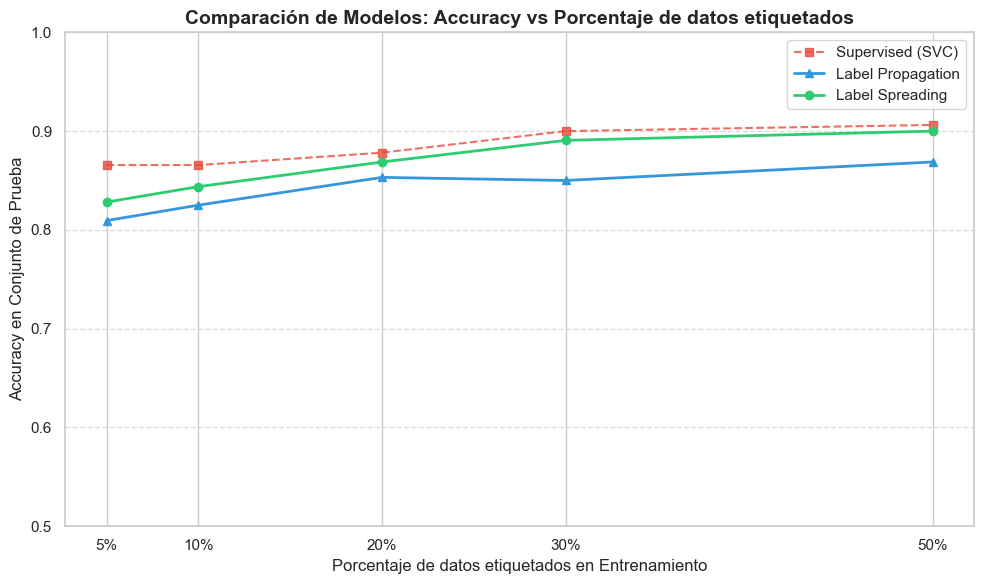

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for model_name in results.keys():
    if 'SVC' in model_name:
        plt.plot(labeled_percentages, results[model_name], marker='s', linestyle='--', label=model_name, color='#e74c3c', alpha=0.8)
    elif 'Spreading' in model_name:
        plt.plot(labeled_percentages, results[model_name], marker='o', linewidth=2, label=model_name, color='#2ecc71')
    else:
        plt.plot(labeled_percentages, results[model_name], marker='^', linewidth=2, label=model_name, color='#3498db')

plt.title('Comparación de Modelos: Accuracy vs Porcentaje de datos etiquetados', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje de datos etiquetados en Entrenamiento', fontsize=12)
plt.ylabel('Accuracy en Conjunto de Prueba', fontsize=12)
plt.xticks(labeled_percentages, [f"{int(p*100)}%" for p in labeled_percentages])
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Resumen Comparativo:**
- **Modelo Supervisado (SVC)**: Cuando el porcentaje de datos es muy pequeño (como 5% o 10%), su desempeño puede estancarse o no generalizar muy bien, debido a la deficiencia de datos de entrenamiento para armar correctamente el hiperplano.
- **Modelos Semi-supervisados (Label Propagation y Label Spreading)**: Dado que estos modelos aprovechan la estructura del grafo basada en distancias y vecinos más próximos, mantienen una robustez superior incluso con bajos porcentajes de datos etiquetados. Aprovechan los clústeres intrínsecos del dataset (en este caso de *Red Wine Quality*) para propagar la etiqueta de forma laplaciana.